# Ch07.앙상블 학습

일련의 예측 모델로부터 예측을 수집하면 가장 좋은 모델 하나보다 더 좋은 예측을 얻을 수 있다. 이를 **앙상블 학습(Ensemble learning)** 이라 한다.

예를 들어 훈련 세트로부터 랜덤으로 각기 다른 서브셋을 만들어 일련의 결정 트리 분류기를 학습시킬 수 있다. 개별 트리의 예측을 모아서 가장 많은 선택을 받은 클래스를 최종 예측으로 삼는다. 결정 트리의 앙상블을 **랜덤 포레스트(Random Forest,RF)** 라고 한다.

이외에도 다양한 앙상블 방법이 있다. 투표 기반 분류기, 배깅과 페이스팅 앙상블, 부스팅, 스태킹 앙상블 등 다양한 방법을 살펴본다.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib as mpl
import matplotlib.font_manager as fm
plt.rc('font', family='Malgun Gothic')  
plt.rcParams['axes.unicode_minus'] = False 


from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline

---

## 7.1 투표 기반 분류기

더 좋은 분류기를 만드는 매우 간단한 방법은 각 분류기의 예측을 집계하는 것이다. 가장 많은 표를 얻은 클래스가 앙상블의 예측이 된다. 이렇게 다수결 투표로 정해지는 분류기를 **직접 투표(Hard voting) 분류기**라고 한다.

<center>

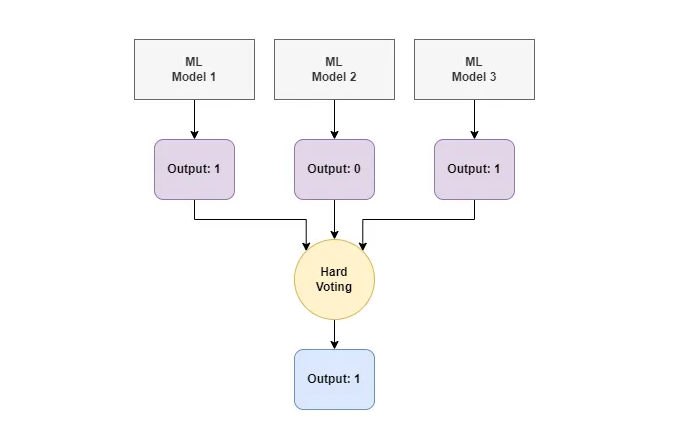

</center>

이 다수결 투표 분류기가 앙상블에 포함된 개별 분류기 중, 가장 뛰어난 모델보다도 정확도가 높은 경우가 많다. 각 분류기가 랜덤 추측보다 조금 너 높은 성능을 내는 **약한 학습기(weak learner)** 여도 앙상블에 충분히 많은 약한 학습기가 충분하게 많고 다양하면 앙상블은 높은 정확도를 내는 **강한 학습기(Strong learner)** 가 될 수 있다.

이 현상은 **대수의 법칙(law of large number)** 으로 설명할 수 있다.

동전을 던졋을 때 앞면이 51%, 뒷면이 49% 확률로 나오는 동전이 있다고 가정하자. 이 동전을 1000번 던지면 대략 510번은 앞면 490번은 뒷면이 나올 것이므로 다수는 앞면이 된다. 수학적으로 계산해보면 1000번을 던진 후 앞면이 다수가 될 확률은 75%에 가깝다는 것을 확인할 수 있으며, 더 많이 던질수록 확률은 증가한다.

이는 대수의 법칙 때문이다. 동전을 계속해서 던질수록 앞면이 나오는 비율은 점점 51%에 가까워진다.

다음 그림은 동전을 계속해서 던지는 실험을 10번한 결과이다. 10번 모두 던진 횟수가 증가할수록 앞면이 나올 확률이 51%에 가까워진다.

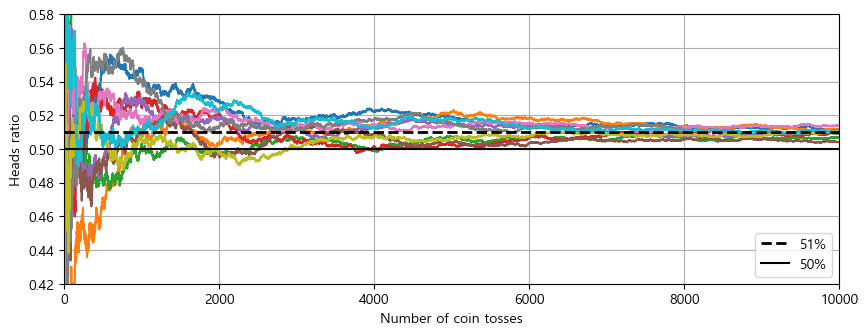

In [2]:
import matplotlib.pyplot as plt
import numpy as np

heads_proba = 0.51
np.random.seed(42)
coin_tosses = (np.random.rand(10000, 10) < heads_proba).astype(np.int32)
cumulative_heads = coin_tosses.cumsum(axis=0)
cumulative_heads_ratio = cumulative_heads / np.arange(1, 10001).reshape(-1, 1)

plt.figure(figsize=(10, 3.5))
plt.plot(cumulative_heads_ratio)
plt.plot([0, 10000], [0.51, 0.51], "k--", linewidth=2, label="51%")
plt.plot([0, 10000], [0.5, 0.5], "k-", label="50%")
plt.xlabel("Number of coin tosses")
plt.ylabel("Heads ratio")
plt.legend(loc="lower right")
plt.axis([0, 10000, 0.42, 0.58])
plt.grid()
plt.show()

이와 비슷하게 51% 정확도를 가진 1000개의 분류기로 앙상블 모델을 구축한다고 가정하자. 가장 많은 클래스를 예측으로 삼는다면 75%의 정확도를 기대할 수 있다.

물론, 여기서 몇가지 가정이 필요하다. **모든 분류기가 완벽하게 독립적이고 오차에 상관관계가 없어야 된다.** 여기서는 같은 데이터로 훈련시키기 때문에 이런 가정이 맞지 않는다. 분류기들이 같은 종류의 오차를 만들기 쉽기 때문에 잘못된 클래스가 다수인 경우가 많고 앙상블의 정확도가 낮아진다.

앙상블 방법은 예측기들이 가능한 한 서로 독립적일 때 높은 성능을 보인다. 따라서 **각기 다른 알고리즘으로 학습**시키는 것이 매우 다른 종류의 오차를 만들 것이며, 앙상블 모델의 정확도가 높아질 것이다.

사이킷런은 이름/예측기 쌍의 리스트를 제공하면 일반 분류기처럼 쉽게 사용할 수 있는 `VotingClassifier` 클래스를 제공한다. 여기서 *moons* 데이터셋을 사용하여 세 가지 분류기로 구성된 투표 기반 분류기를 생성하고 훈련한다.

In [3]:
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

X,y = make_moons(n_samples=500,noise=0.3,random_state=42)
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42)

voting_clf = VotingClassifier(
    estimators = [
        ('lr',LogisticRegression(random_state=42)),
         ('rf',RandomForestClassifier(random_state=42)),
         ('svc',SVC(random_state=42))
    ]
)

voting_clf.fit(X_train,y_train);

`VotingClassifier`를 훈련할 때 이 클래스는 모든 추정기를 복제하여 복제된 추정기를 훈련한다. 원본 추정기는 `estimators` 속성을 통해 참조할 수 있으며, 훈련된 복제본은 `estimators_` 속성에 저장된다. 리스트 대신 딕셔너리를 전달하는 경우 `named_estimators` 또는 `named_estimators_`를 사용할 수 있다.

먼저 테스트 세트에서 훈련된 각 분류기의 정확도를 살펴본다.

In [4]:
for name, clf in voting_clf.named_estimators_.items():
    print(name, '=',clf.score(X_test,y_test))

lr = 0.864
rf = 0.896
svc = 0.896


투표 기반 분류기의 `predict()` 메서드를 호출하면 직접 투표를 수행한다. 예를 들어 이 투표 기반 분류기는 테스트 세트의 첫 번째 샘플에 대해 클래스 1을 예측하는데, 이 세 분류기 중 두 분류기가 해당 클래스를 예측하기 때문이다.

In [5]:
print(voting_clf.predict(X_test[:1]))
print([clf.predict(X_test[:1]) for clf in voting_clf.estimators_])

[1]
[array([1], dtype=int64), array([1], dtype=int64), array([0], dtype=int64)]


이제 테스트 세트에서 투표 기반 분류기의 성능을 살펴본다.

In [6]:
voting_clf.score(X_test,y_test)

0.912

투표 기반 분류기가 다른 개별 분류기보다 성능이 조금 더 높다.

모든 분류기가 클래스의 확률을 예측할 수 있으면, 즉 `predict_proba()` 메서드가 있으면 개별 분류기의 예측을 평균 내어 확률이 가장 높은 클래스를 예측할 수 있다. 이를 **간접 투표(Soft voting)** 라고 한다. 회귀를 위한 앙상블에서도 간접 투표로 예측값의 평균을 최종 예측으로 한다.

이 방식은 확률이 높은 투표에 더 비중을 두기 때문에 직접 투표 방식보다 성능이 더 높다. 이 방식을 사용하기 위해서는 투표 기반 분류기의 `voting` 파라미터를 `soft`로 바꾸고 모든 분류기가 클래스의 확률을 추정할 수 있도록 하면 된다. `SVC`는 기본값에서 클래스 확률을 제공하지 않으므로 `probability=True`로 지정해야 한다.

In [7]:
voting_clf.voting='soft'
voting_clf.named_estimators['svc'].probability = True
voting_clf.fit(X_train,y_train)
voting_clf.score(X_test,y_test)

0.92

---

## 7.2 배깅과 페이스팅

다양한 분류기를 만드는 한 가지 방법은 각기 다른 훈련 알고리즘을 사용하는 것이다. 또 다른 법은 같은 알고리즘을 사용하되, **훈련 세트의 서브셋을 랜덤으로 구성하여 분류기를 각기 다르게 학습**시키는 것이다.

훈련 세트에 중복을 허용하여 샘플링하는 방식을 **배깅(Bootstrap aggregating,Bagging)** 이라 하며, 중복을 허용하지 않고 샘플링을 하는 방식을 **페이스팅(pasting)** 이라고 한다.

배깅과 페이스팅에서는 같은 훈련 샘플을 여러 개의 예측기에 걸쳐 사용할 수 있다. 하지만 배깅만이 한 예측기를 위해 같은 훈련 샘플을 여러 번 샘플링할 수 있다.

<center>

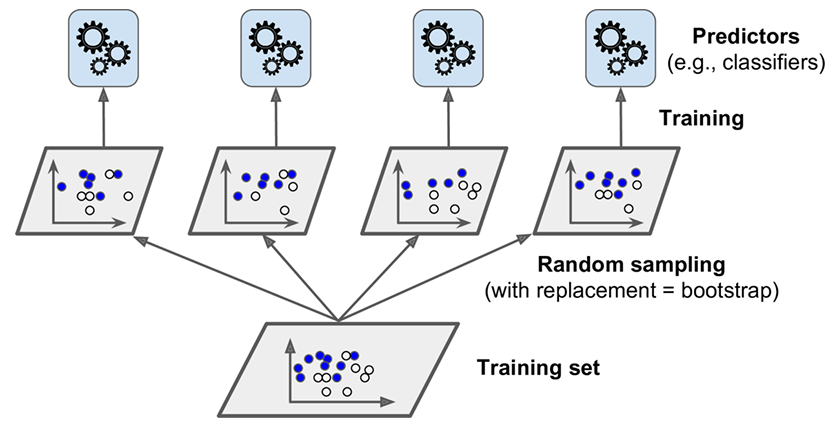

</center>

모든 예측기가 훈련을 마치면 앙상블은 모든 예측기의 예측을 모아서 새로운 샘플에 대한 예측을 만든다. 집계 함수는 분류일 때는 일반적으로 직접 투표 분류기처럼 가장 많은 예측 결과인 **통계적 최빈값**을, 회귀에 대해서는 **평균**을 계산한다. 개별 예측기는 원본 훈련 세트를 훈련시킨 것보다 크게 편향되어 있지만 집계 함수를 통과하면 편향과 분산이 모두 감소한다. 일반적으로 앙상블의 결과는 원본 데이터셋으로 하나의 예측기를 훈련시킬 때와 비교했을 때, 편향은 비슷하지만 분산은 감소한다.

예측기는 동시에 다른 CPU 코어나 서버에서 병렬로 학습시킬 수 있다. 이와 유사하게 예측도 병렬로 수행할 수 있다. 이런 확정성 덕분에 배깅과 페이스팅의 인기가 높다.

### 사이킷런의 배깅과 페이스팅

사이킷런은 배깅과 페이스팅을 위해 `BaggingClassifier` , `BaggingRegressor`를 제공한다. 다음은 결정 트리 분류기 500개의 앙상븧을 훈련시키는 코드이다. 각 분류기는 훈련 세트에서 중복을 허용하여 랜덤으로 선택된 100개의 샘플로 훈련된다. 페이스팅을 사용하고 싶다면 위의 사이킷런 배깅 클래스에서 `bootstrap=False`로 지정하면 된다.

`BaggingClassifier`는 기반이 되는 분류기가 결정 트리처럼 클래스 확률을 추정할 수 있으면 직접 투표 대신 간접 투표 방식을 사용한다.

In [8]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(DecisionTreeClassifier(),n_estimators=500,
                            max_samples=100,n_jobs=-1,random_state=42)

##max_samples를 0~1 사이 실수로 지정하면 샘플링되는 데이터 수는 훈련 세트의 크기에 max_samples를 곱한 값이 된다.

bag_clf.fit(X_train,y_train);

다음 그림은 단일 결정 트리의 결정 경계와 500개의 트리를 사용한 배깅 앙상블의 결정 경계를 비교한 것이다.

<center>

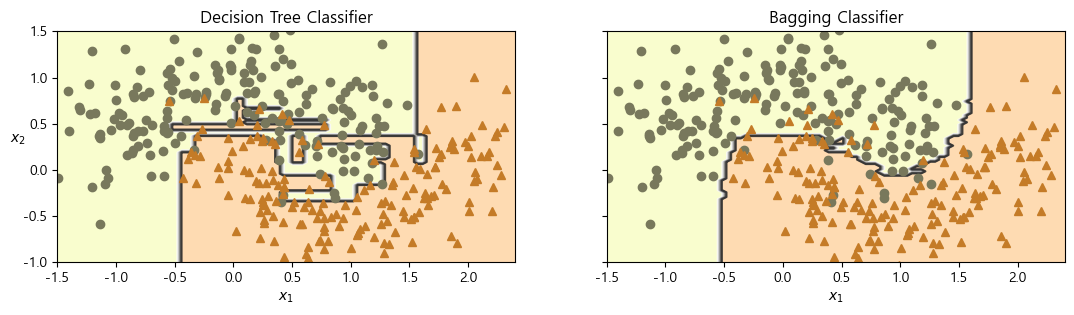

</center>

앙상블의 예측이 하나의 결정 트리보다 더 일반화가 잘 되었다.

배깅은 각 예측기가 학습하는 서브셋에서 다양성을 추가하므로 배깅이 페이스팅보다 편향이 조금 더 높다. 하지만 다양성을 추가한다는 것은 예측기들의 상관관계를 줄이므로 앙상블의 분산이 더 줄어든다는 것을 의미한다. 전반적으로 배깅이 더 나은 모델을 만들기 때문에 선호되지만, 시간과 CPU 파워에 여유가 있다면 교차 검증으로 배깅과 페이싕을 모드 평가해서 더 나은 쪽을 선택하는 것이 좋다.

### OOB 평가

배깅을 사용하면 어떤 샘플은 한 예측기를 위해 여러 번 샘플링되고 어떤 것은 전혀 선택되지 않을 수 있다. `BaggingClassifier`는 기본값으로 중복을 허용하여 훈련 세트의 크기인 $m$개 샘플을 선택한다.

$m$개의 샘플에서 랜덤으로 하나를 추출할 때, 선택되지 않을 확률은 $1-\frac{1}{m}$ 이다. 이를 $m$번 반복했을 때도 선택되지 않을 확률은 $(1-\frac{1}{m})^m$이다. 잘 보면 이는 자연로그의 밑인 $e$의 정의와 비슷하다. $m$이 커지면 커질수록, 이 값은 $e^{-1}$에 가까워진다. 

따라서 하나의 샘플이 샘플링될 확률은 $1-e^{-1}=0.63212$에 가까워지므로, **훈련 세트의 크기인 $m$개 샘플을 선택하면 평균적으로 각 예측기에 훈련 샘플의 63% 정도만 샘플링된다는 것을 의미한다.**

선택되지 않은 나머지 37%를 *Out-of-Bag(OOB)* 샘플이라 부르며, 예측기마다 다른 OOB 샘플이 생성된다.

예측기가 훈련되는 동안에는 OOB 샘플을 사용하지 않으므로 별도의 검증 세트를 사용하지 않고 OOB 샘플을 사용해 평가할 수 있다. 앙상블의 평가는 각 예측기의 OOB 평가를 평균내어 얻는다.

사이킷런에서 `BaggingClassifier`를 만들 때 `oob_score=True`로 지정하면 훈련이 끝난 후 자동으로 OOB 평가를 수행한다. 평가 점수 결과는 `oob_score_` 변수에 저장된다.

In [9]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(),n_estimators=500,
                           oob_score=True, n_jobs=-1, random_state=42)

bag_clf.fit(X_train,y_train);
bag_clf.oob_score_

0.896

OOB 평가 결과를 살펴보면 이 `BaggingClassifier`는 테스트 세트에서 약 89.6%의 정확도를 얻을 것으로 보인다.

In [10]:
from sklearn.metrics import accuracy_score
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.92

테스트 세트에서 91.2%의 정확도를 얻었다. OOB 평가는 2% 정도 낮다.

OOB 샘플에 대한 결정 함수의 값도 `oob_decision_function_` 변수에서 확인할 수 있다. 기반이 되는 예측기가 `predict_proba()` 메서드를 가지고 있기 때문에 결정 함수는 각 훈련 샘플의 클래스 확률을 반환한다.

다음 예를 보면 OOB 평가는 첫 번째 훈련 샘플이 양성 클래스에 속할 확률을 67.6%, 음성 클래스에 속할 확률을 32.4%로 추정하고 있다.

In [11]:
## 처음 3개의 샘플에 대한 확률
bag_clf.oob_decision_function_[:3]

array([[0.32352941, 0.67647059],
       [0.3375    , 0.6625    ],
       [1.        , 0.        ]])

---

## 7.3 랜덤 패치와 랜덤 서브스페이스

`BaggingClassifier`는 변수 샘플링도 지원한다. 샘플링은 `max_features`,`bootstrap_features` 두 파라미터로 조절된다. `max_samples`,`bootstrap`과 동일한 방식으로 작동하지만, 샘플이 아닌 **설명변수**에 대한 샘플링에 사용된다. 따라서 각 예측기는 랜덤으로 선택한 설명변수의 일부분으로 훈련된다.

이 기법은 훈련 속도를 크게 높일 수 있기 때문에 고차원의 데이터셋을 다룰 때 유용하다. 훈련을 위해 샘플과 설명변수 모두 샘플링하는 것을 **랜덤 패치 방식(Random patches method)** 라고 한다. `bootstrap=False`,`max_samples=1.0`으로 설정하여 **훈련 샘플을 모두 사용**하고, `bootstrap_features=True`로 설정하고 `max_features`를 1.0보다 작게 설정하여 **설명변수를 샘플링**하는 것은 **랜덤 서브스페이스 방식(Random subspaces method)** 이라고 한다.

설명변수 샘플링은 더 다양한 예측기를 만들어 편향을 늘리는 대신, 분산을 감소시킨다.

---

## 7.4 랜덤 포레스트

**랜덤 포레스트**는 일반적으로 배깅(혹은 페이스팅)을 적용한 결정 트리의 앙상블이다. `BaggingClassifier`에 `DecisionTreeClassifier`를 넣어 만드는 대신 결정 트리에 최적화되어 사용하기 편리한 `RandomForestClassifier`를 사용할 수 있다 (회귀에선 `RandomForestRegressor`를 사용한다). 하지만 `BaggingClassifier`는 결정 트리 이외의 모델을 앙상블하고 싶을 때 여전히 유용하다

다음은 최대 16개의 리프 노드를 갖는 500개의 트리로 이뤄진 랜덤 포레스트 분류기를 가능한 모든 CPU 코어에서 훈련시키는 코드이다.

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16,
                                 n_jobs=-1, random_state=42)
##n_jobs = -1 -> CPU의 모든 코어 사용

rf_clf.fit(X_train,y_train)

y_pred_rf = rf_clf.predict(X_test)

`RandomForestClassifier`는 몇 가지 예외가 있지만, 트리의 성장을 조절하기 위한 `DecisionTreeClassifier`의 파라미터와 앙상블 자체를 제어하는 데 필요한 `BaggingClassifier`의 파라미터를 모두 가지고 있다.

랜덤 포레스트 알고리즘은 트리의 노드를 분할할 때 전체 설명변수 중에서 최선의 변수를 찾는 대신 랜덤으로 선택한 변수 후보 중에서 최적의 변수로 분할을 찾는 식으로 무작위성을 더 추가한다. 기본적으로 $\sqrt{n}$개의 변수를 선택한다. 이는 결국 트리를 더욱 다양하게 만들고 편향을 감수하면서 분산을 낮추어 전체적으로 더 훌륭한 모델을 만들어낸다.

다음은 `BaggingClassifier`를 앞의 `RandomForestClassifier`와 거의 동일하게 만든 것이다.

In [13]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(max_features='sqrt',max_leaf_nodes=16),
    n_estimators=500, n_jobs=-1, random_state=42)

### 엑스트라 트리

랜덤 포레스트에서 트리를 만들 때, **각 노드에서 랜덤으로 설명변수를 지정한 수만큼 뽑는다. 그리고 선택된 설명변수들 중 최적의 분할을 탐색하는 방식으로 학습한다.**

여기서 더욱 트리를 랜덤하게 만들기 위해선, 최적의 임계값을 찾는 대신 각 노드에서 **샘플링된 설명변수들마다 랜덤으로 임계값을 선택**한다. 그 중 최상의 분할을 선택하여 학습한다. 이렇게 하려면 `DecisionTreeClassifier`를 만들 때 `splitter='random'`으로 지정하면 된다.

이와 같이 더욱 극단적으로 랜덤한 트리의 랜덤 포레스트를 **익스트림 랜덤 트리(extremely randomized tree) 앙상블** 또는 줄여서 **엑스트라 트리(extra-tree)** 라고 한다. 여기서도 편향이 증가하는 대신 분산이 낮아진다. 모든 노드에서 변수마다 가장 최적의 임계값을 찾는 것은 트리 알고리즘에서 가장 시간이 많이 소요되는 작업이므로 랜덤 포레스트보다 엑스트라 트리의 훈련 속도가 훨씬 빠르다.

엑스트라 트리를 만들려면 사이킷런의 `ExtraTreeClassifier`를 사용한다. `bootstrap` 파라미터가 기본적으로 `False`인 것을 제외하면 사용법은 `RandomForestClassifier`와 같다. `ExtraTreeRegressor`도 동일하다.

랜덤 포레스트와 엑스트라 트리 중, 어떤 것이 더 좋고 나쁜지는 교차 검증으로 비교해보는 것이 유일한 방법이다.

### 변수 중요도

랜덤 포레스트는 변수의 상대적 중요도를 측정하기 쉽다. 사실 결정 트리를 기반으로 하는 모델은 모두 변수 중요도를 제공한다. 하지만 일반적인 결정 트리는 매 분할에 최적의 변수와 임계값을 분할로 사용하기에 몇몇 변수를 완전히 배제하는 반면 랜덤 포레스트는 무작위성이 주입되므로 거의 모든 변수에 대해 평가할 기회를 가진다.

랜덤 포레스트에 있는 모든 트리에 걸쳐서, 어떤 변수를 사용한 노드가 평균적으로 불순도를 얼마나 감소시키는지 확인하여 변수 중요도를 측정한다. 더 정확하게는 가중치 평균이며, 각 노드의 가중치는 연돤된 훈련 샘플 수와 같다.

사이킷런은 훈련이 끝난 뒤 변수마다 자동으로 이 점수를 계산하고 중요도의 전체 합이 1이 되도록 결과값을 정규화한다. 이 값은 `feature_importances_` 변수에 저장되어 있다.

다음 코드는 *iris* 데이터셋에 `RandomForestClassifier`를 훈련시키고 각 변수의 중요도를 출력한다.

In [14]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
rnd_clf = RandomForestClassifier(n_estimators=500, random_state=42)
rnd_clf.fit(iris.data, iris.target)
for score, name in zip(rnd_clf.feature_importances_, iris.data.columns):
    print(round(score, 2), name)

0.11 sepal length (cm)
0.02 sepal width (cm)
0.44 petal length (cm)
0.42 petal width (cm)


이와 유사하게 MNIST 데이터셋에 랜덤 포레스트 분류기를 훈련시키고 각 픽셀의 중요도를 그래프로 나타내면 다음과 같은 이미지를 얻게 된다.

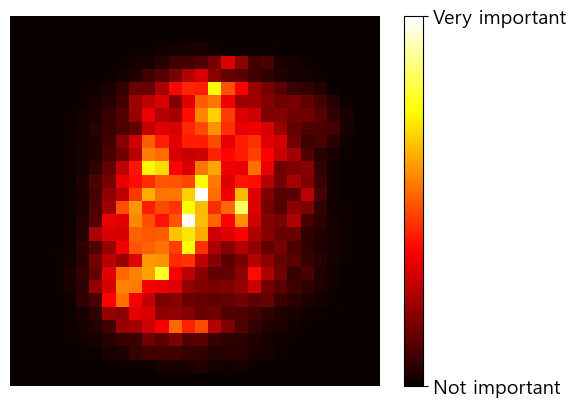

In [15]:
from sklearn.datasets import fetch_openml


X_mnist, y_mnist = fetch_openml('mnist_784', return_X_y=True,
                                as_frame=False, parser='auto')

rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rnd_clf.fit(X_mnist, y_mnist)

heatmap_image = rnd_clf.feature_importances_.reshape(28, 28)
plt.imshow(heatmap_image, cmap="hot")
cbar = plt.colorbar(ticks=[rnd_clf.feature_importances_.min(),
                           rnd_clf.feature_importances_.max()])
cbar.ax.set_yticklabels(['Not important', 'Very important'], fontsize=14)
plt.axis("off")
plt.show()

랜덤 포레스트는 변수를 선택해야 할 때, 어떤 변수가 중요한지 빠르게 확인할 수 있어 매우 편리하다

---

## 7.5 부스팅

**부스팅(boosting)** 은 약한 학습기를 여러 개 연결하여 강한 학습기를 만드는 앙상블 방법을 말한다. 부스팅 방법의 아이디어는 앞의 모델을 보완해 나가면서 일련의 예측기를 학습시키는 방법이다. 부스팅 방법에는 여러 가지가 있지만, **AdaBoost(Adaptive Boosting)** 과 **그래디언트 부스팅(Gradient Boosting)** 이 자주 사용된다.

### 1. AdaBoost

이전 예측기를 보완하는 새로운 예측기를 만드는 방법은 이전 모델이 과소적합했던 훈련 샘플의 가중치를 더 높이는 것이다. 이렇게 하면 새로운 예측기는 학습하기 어려운 샘플에 점점 더 맞춰지게 된다. 이것이 **AdaBoost**에서 사용하는 방식이다.

AdaBoost에서 분류기를 만들 때, 먼저 알고리즘이 기반이 되는 첫 번째 분류기(대부분 결정 트리)를 훈련 세트에서 훈련시키고 예측을 만든다. 그런 다음 알고리즘이 잘못 분류된 훈련 샘플의 가중치를 상대적으로 높인다. 두 번째 분류기는 업데이트된 가중치를 사용해 훈련 세트에서 훈련하고 다시 예측을 만든다. 그리고 다시 가중치를 업데이트하는 방식으로 계속된다.

<center>

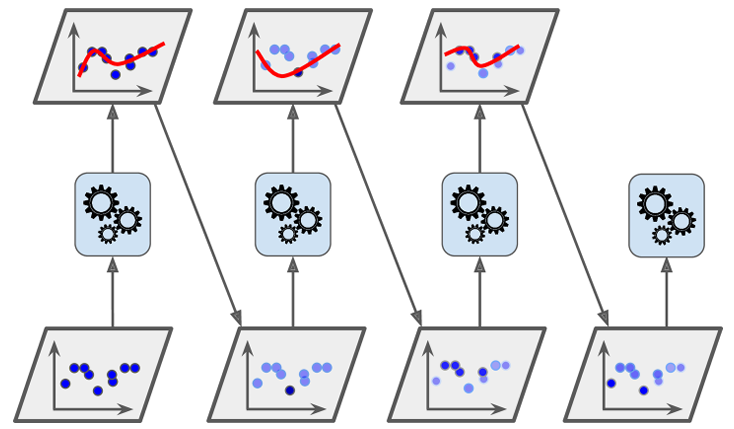

</center>

다음 그림은 *moons* 데이터셋에 훈련시킨 다섯 개의 연속된 SVM 분류기의 결정 경계이다(SVM은 속도가 느리고 AdaBoost와 함께 사용했을 때 불안정ㅎ한 경향이 있어 부스팅 기반 예측기로 적합하지 않다).

<center>

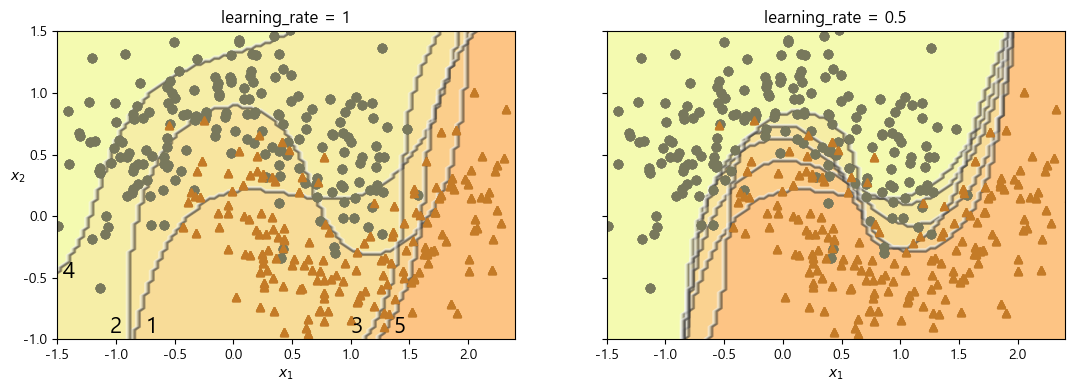

</center>

첫 번째 분류기가 많은 샘플을 잘못 분류해서 이 샘플들의 가중치가 높아졌다. 따라서 두 번째 분류기는 이 샘플들을 더정확히 예측하게 된다. 오른쪽 그래프는 학습률을 반으로 낮춘 것만 빼고 똑같은 일련의 예측기를 나타낸 것이다(잘못 분류된 샘플의 가중치는 반복마다 절반 정도만 높아진다).

그림에서 볼 수 있듯이 이런 연속된 학습 기법은 경사하강법과 비슷한 면이 있다. 경사하강법은 비용함수를 최소화하기 위해 한 예측기의 모델 파라미터를 조정해가는 반면, AdaBoost는 점차 더 좋아지도록 앙상블에 예측기를 추가한다.  
모든 예측기가 훈련을 마치면 이 앙상블은 배깅이나 페이스팅과 비슷한 방식으로 예측을 만든다. 하지만 가중치가 적용된 훈련 세트의 전반적인 정확도에 따라 예측기마다 다른 가중치가 적용된다.

다만, 연속된 학습 기법에서 각 예측기는 이전 예측기가 훈련되고 평가된 후에 학습될 수 있기 때문에 훈련을 병렬화할 수 없다.

다음 코드는 사이킷런의 `AdaBoostClassifier`를 사용하여 200개의 얕은 결정 트리를 기반으로 하는 AdaBoost 분류기를 훈련시킨다. 회귀는 `AdaBoostRegressor`를 사용하면 된다.

In [19]:
from sklearn.ensemble import AdaBoostClassifier

ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1),n_estimators=200,
    learning_rate=0.5,random_state=42)

ada_clf.fit(X_train,y_train);

`AdaBoostClassifier`는 `DecisionTreeClassifier(max_depth=1)` , `AdaBoostRegressor`는 `DecisionTreeRegressor(max_depth=3)`을 기본 예측기로 사용한다. 이렇게 얕고 단순한 트리를 사용하는 이유는 AdaBoost가 오차를 반복적으로 보완하는 방식이기 때문이며, 이런 약한 예측기들을 **그루터기(Decision Stump)** 라고 부른다.

#### AdaBoost 분류 알고리즘

먼저 **AdaBoost 분류**를 자세히 살펴본다. 각 샘플 가중치 $w^{(i)}$는 초기에 $1/m$으로 초기화된다. 첫 번째 예측기가 학습되고, 가중치가 적용된 오류율 $r_1$이 훈련 세트에 대해 계산된다.

- $AdaBoost\ weighted\ error\ rate\ of\ the\ jth\ predictor$
$$
r_j=\frac{\sum_{i=1}^{m}w^{(i)}I(\hat{y}^{(i)}_j \neq y^{(i)})}{\sum_{i=1}^{m}w^{(i)}}
$$

여기서 $\hat{y}^{(i)}_j$는 $i$번째 샘플에 대한 $j$번째 예측기의 예측이며, $I(\cdot)$은 지시함수(*Indicator function*)이다.

예측기의 가중치 $\alpha_j$는 다음 식을 사용해 계산된다.

- $AdaBoost\ predictor\ weight$
$$
\alpha_j = \eta \log\frac{1-r_j}{r_j}
$$

$\eta$는 학습률 하이퍼파라미터이며, 기본값은 1이다. 예측기가 정확할수록 가중치는 더 높아진다. 만약 랜덤으로 예측하여 $r$이 0.5에 가까워지면 $(1-r)/r \approx 1$이 되므로 예측기 가중치가 0에 가까워진다. 예측기가 랜덤 예측보다 정확도가 낮으면 $(1-r)/r \lt 1$가 되어 예측기 가중치가 음수가 된다.

다음으로 AdaBoost 알고리즘이 다음 식을 사용해 샘플의 가중치를 업데이트한다. 잘못 분류된 샘플의 가중치가 높아진다.


- $AdaBoost\ sample\ weight\ update\ rule$
$$
w^{(i)} \leftarrow \begin{cases} w^{(i)} & \text{if } \hat{y}_j^{(i)} = y^{(i)} \\ w^{(i)} \cdot \exp(\alpha_j) & \text{if } \hat{y}_j^{(i)} \ne y^{(i)} \end{cases}
$$

그런 다음 모든 샘플의 가중치를 $\sum_{i=1}^{m}w^{(i)}$로 나눠 정규화한다.

마지막으로, 새 예측기의 가중치가 계산되고 샘플의 가중치를 업데이트해서 또 다른 예측기를 훈련시키는 과정을 반복한다. 이 알고리즘은 지정한 예측기 수에 도달하거나 완벽한 예측기가 만들어지면 중지된다.

예측을 할 때 AdaBoost는 모든 예측기의 예측을 계산하고 예측기 가중치 $\alpha_j$를 더해 예측 결과를 만든다. 가중치 합이 가장 큰 클래스가 예측 결과가 된다.

- $AdaBoost\ prediction$
$$
\hat{y}(\mathbf{x})=\underset{k}{\argmax}\sum_{j=1}^{N}\alpha_j I(\hat{y}_j(\mathbf{x})=k)
$$

$N$은 예측기의 개수이다.

사이킷런은 **SAMMA**라는 AdaBoost의 다중 클래스 버전을 사용한다. SAMMA 알고리즘의 예측기 가중치는 다음과 같이 계산한다.

- $SAMMA\ predictor\ weight$
$$
\alpha_j = \eta (\log\frac{1-r_j}{r_j}+\log(K-1))
$$

따라서 이진 분류인 경우 SAMMA와 AdaBoost는 같은 알고리즘이 된다.

개별 예측기가 클래스의 확률을 추정할 수 있는 `predict_proba()` 메서드가 있다면 사이킷런은 SAMMA의 변형인 SAMMA.R을 사용한다. 이 알고리즘은 예측값 대신 **클래스 확률을 기반**으로 하며 일반적으로 성능이 더 좋다.  
SAMMA.R 알고리즘의 예측기 가중치는 다음과 같이 계산한다.

- $SAMMA.R\ predictor\ weight$
$$
\alpha_j = -\eta \frac{K-1}{K}\ y\log\hat{y}_i
$$

여기서 $y$는 정답 클래스일 때 1, 아니면 $-\frac{1}{K-1}$이고, $\hat{y}_j$는 $j$번째 예측기가 만든 클래스 확률이다. 예측을 할 때는 다음 공식으로 예측기별 클래스 확률을 계산해서 합한 후 확률이 가장 높은 클래스를 선택한다.

- $SAMMA.R\ prediction$
$$
\hat{y}(\mathbf{x})=\underset{k}{\argmax}\sum_{j=1}^{N}(K-1)(\log\hat{y}_j-\frac{1}{K} \sum_{k=0}^{K}\hat{y}_j)
$$

#### AdaBoost 회귀

다음으로 **AdaBoost 회귀**에 대해 살펴본다. 사이킷런의 `AdaBoostRegressor`는 **AdaBoost.R2** 알고리즘을 회귀에 사용한다. 예측기의 신뢰도는 $\beta_j = L_j/(1-L_j)$를 $L_j = \sum_{i=1}^{m}w^{(i)}v_j$로 계산한다.

먼저, AdaBoost.R2 알고리즘은 예측기의 성능 가중치(신뢰도라고도 함)인 $\beta_j = L_j/(1-L_j)$으로 개별 예측기의 가중치를 계산한다. 여기서 $L_j = \sum_{i=1}^{m}w^{(i)}v_j$은 분류에서의 $r_j$에 해당한다.

여기서 $v_j$는 $j$번째 예측기가 만드는 평균 오차이며, `AdaBoostRegressor`의 `loss` 파라미터에 따라 다르게 정의된다.  

- `linear` (기본값) : $v_j = \frac{|\hat{y}-y|}{|\hat{y}-y|_{max}}$  

- `square` : $v_j = v_{linear}^2$  

- `exponential` : $v_j = 1-e^{-v_{linear}}$


예측치의 가중치 계산과 가중치 업데이트는 다음과 같이 계산한다.

- $AdaBoost.R2\ predictor\ weight$  
$$
\alpha_j = \eta\ \log(\frac{1}{\beta})
$$

- $AdaBoost.R2\ sample\ weight\ update\ rule$
$$
w^{(i)}=w^{(i)}\beta^{(1-v_j)\eta}
$$

예측을 할 땐, 예측기의 결과값을 순서대로 정렬하여 **각 예측기 가중치의 누적값이 중간이 되는 지점에 있는 예측기의 결과를 사용**한다. 이 예측 방식은 **가중 중앙값(weighted median)** 개념으로, 가중치가 높은 예측기 중심으로 예측값을 산출한다는 뜻이다.

### 2. 그래디언트 부스팅

최근 많이 사용되며 좋은 성능을 보이는 부스팅 알고리즘은 **그래디언트 부스팅(Gradient Boosting)** 이다. AdaBoost처럼 그래디언트 부스팅은 앙상블에 이전까지의 오차를 보정하도록 예측기를 순차적으로 추가한다. 하지만 AdaBoost처럼 매 반복마다 샘플의 가중치를 수정하는 대신, **이전 예측기가 만든 잔차(residual)에 새로운 예측기를 학습시킨다.**

결정 트리를 개별 예측기로 사용하는 간단한 회귀 문제를 살펴본다. 이를 그래디언트 트리 부스팅 또는 GBRT라고 한다. 먼저 2차 방정식으로 잡음이 섞인 데이터셋을 생성하고 `DecisionTreeRegressor`를 학습시킨다.